# 深層生成モデル 第7回演習



## 目次．

1. [前準備](#scrollTo=RPztR4LdyZTX)
1. [DDPMの復習](#scrollTo=FNqDX1ttNoGb)
1. [ネットワークの定義](#scrollTo=nFEDhMID0qLG)
1. [データセット / データローダー](#scrollTo=lq3J_3sCrKGd)
1. [学習 (Algorithm 1) の実装](#scrollTo=a30368b2)
1. [サンプリング (Algorithm 2) の実装](#scrollTo=4cf98443)
1. [学習の実行](#scrollTo=f70235f8)
1. [参考文献](#scrollTo=GqsgqmNd1ejC)

本演習では，**Denoising Diffusion Probabilistic Models (DDPM)**を扱います．論文はHo et al., 2020 [[1]](https://arxiv.org/abs/2006.11239)です．

DDPMは，[Stable Diffusion](https://arxiv.org/abs/2205.11487)，[DALL-E 2](https://openai.com/dall-e-2/)，[Imagen](https://imagen.research.google/)や[GLIDE](https://arxiv.org/abs/2112.10741)といった最近の有名なtext-to-imageモデルの基礎となっているものです．音声や自然言語といった領域においても広く応用されています．（[参考](https://github.com/heejkoo/Awesome-Diffusion-Models)）

拡散過程とその逆過程を利用した生成モデルは以前から提案されていましたが [[2]](https://arxiv.org/abs/1503.03585)，DDPMを主なきっかけとして，拡散モデルが注目されることになりました．

- 拡散確率モデルとdenoising score matchingの対応を示した

- U-Net構造を用いて，拡散確率モデルがハイクオリティな画像を生成できることを実証した


## 1.前準備

ランタイムのタイプがGPUになっていない場合は変更してください．

In [ ]:
!nvidia-smi

必要なライブラリのインストールとインポート

In [ ]:
!pip install -q -U einops datasets

import math
from inspect import isfunction
from functools import partial

import matplotlib.pyplot as plt
from matplotlib import animation, rc
from tqdm.auto import tqdm
from einops import rearrange, repeat

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch import einsum
import torchvision
from torchvision import transforms
from torchvision.utils import save_image

from datasets import load_dataset

from PIL import Image
import requests

from IPython import display
import pylab as pl

%matplotlib inline

## 2.DDPMの復習

<figure align="center"><img src=" 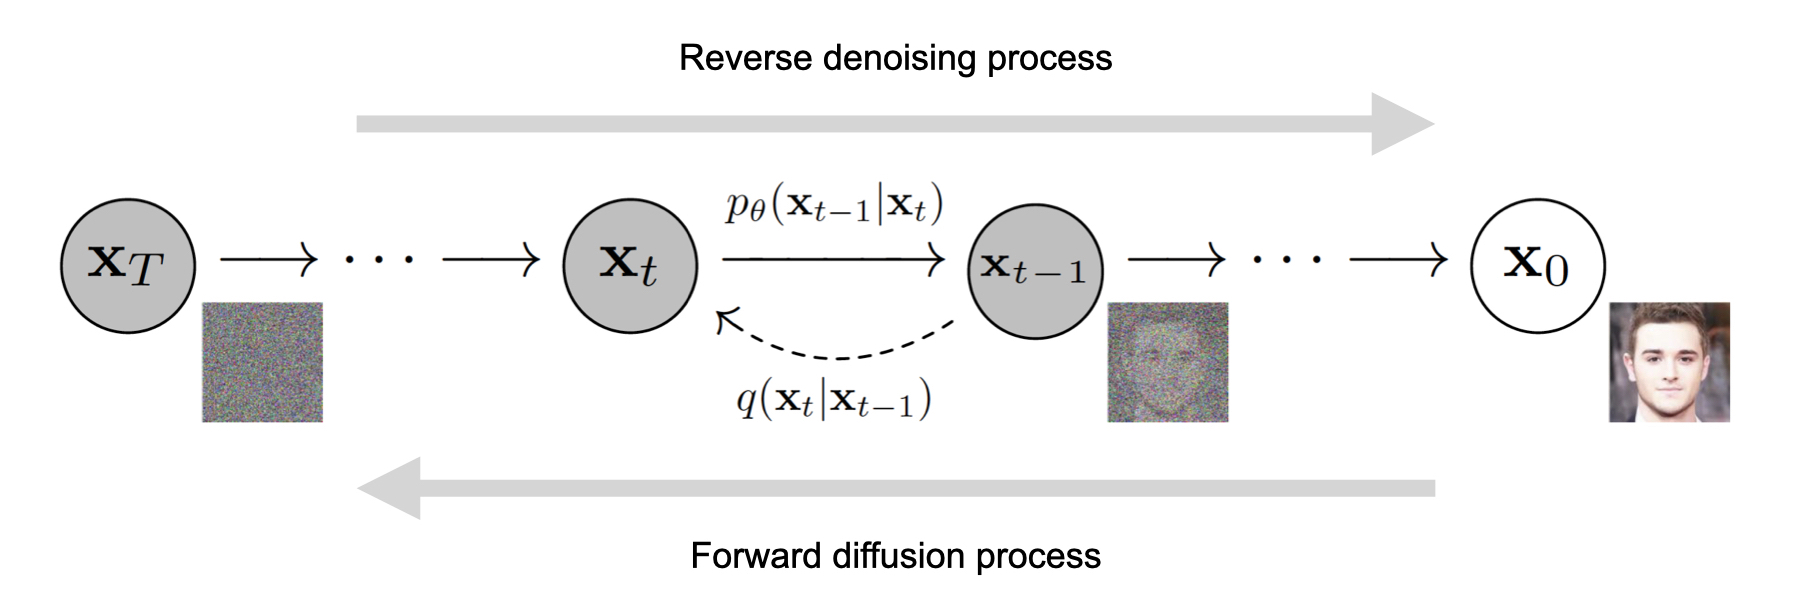" width="600"><figcaption>Ho et al., 2020</figcaption></figure>

### 2.1 Forward diffusion process (拡散過程)

<br>

データ分布からのサンプル$\mathbf{x}_0 \sim q(\mathbf{x})$に対して，$T$ステップ微小なガウシアンノイズを加えるプロセス．ノイズの入ったサンプル$\mathbf{x}_1,...,\mathbf{x}_T$は潜在変数とみることができます．

プロセス全体は以下の事後分布．

$$
q(\mathbf{x}_{1:T}|\mathbf{x}_0) := \prod^T_{t=1} q(\mathbf{x}_t|\mathbf{x}_{t-1})
$$

1ステップは以下です．拡散率$\{\beta_t \in (0,1)\}_{t=1}^T$は，ここではあらかじめスケジューリングされます．

$$
q(\mathbf{x}_t|\mathbf{x}_{t-1}) := \mathcal{N}(\mathbf{x}_t;\sqrt{1-\beta_t}\mathbf{x}_{t-1}, \beta_t\mathbf{I})
$$

**Notes**

- Forward diffusion processには**学習可能なパラメータがない**

- $T \rightarrow \infty$とすると，$\mathbf{x}_T$はガウス分布からのサンプルと同等になる

以下のような逐次的な式変形をすることで，reparameterizationによって**任意のステップにおける $\mathbf{x}_t$ が $\mathbf{x}_0$ から直接サンプリングできる**ことがわかります．

- ただし $\alpha_t := \Pi_{s=1}^{t} 1 - \beta_s$

\begin{aligned}
\mathbf{x}_t
&= \sqrt{1 - \beta_t}\mathbf{x}_{t-1} + \sqrt{\beta_t}\epsilon_{t-1} \\
&= \sqrt{(1 - \beta_t)(1 - \beta_{t-1})}\mathbf{x}_{t-2} + \sqrt{1 - (1 - \beta_t)(1 - \beta_{t-1})} \bar{\epsilon}_{t-2} \\
&= ...\\
&= \sqrt{\alpha_t} \mathbf{x}_0 + \sqrt{1- \alpha_t} \mathbf{\epsilon}_t
\qquad \epsilon_t \sim \mathcal{N}(0,I)\\
\end{aligned}

<!--
$$
q(\mathbf{x}_t|\mathbf{x}_0) &= \mathcal{N}(\mathbf{x}_t;\sqrt{\alpha_t}\mathbf{x}_0, (1-\alpha_t)I)
$$
-->

### 2.2 Reverse denoising process (逆過程)

<br>

Forward diffusion processを逆にし，ノイズサンプル$\mathbf{x}_T \sim \mathcal{N}(0,I)$から徐々にノイズ除去をして画像を得るプロセス．$q(\mathbf{x}_{t-1}|\mathbf{x}_t)$は直接計算できないので，$p_{\theta}$で近似します．

プロセス全体は以下の同時分布．

$$
p_{\theta}(\mathbf{x}_{0:T}) := p(\mathbf{x}_T) \prod^T_{t=1} p_{\theta}(\mathbf{x}_{t-1}|\mathbf{x}_t)
$$

1ステップは以下になります．

$$
p_{\theta}(\mathbf{x}_{t-1}|\mathbf{x}_t) := \mathcal{N}(\mathbf{x}_{t-1};\mu_{\theta}(\mathbf{x}_t,t), \Sigma_{\theta}(\mathbf{x}_t,t))
\qquad p(\mathbf{x}_T) = \mathcal{N}(0, I)
$$

**Notes**

- ガウス分布の拡散過程のステップサイズ（拡散率）が**十分に小さければ**，その逆過程もガウス分布とみなせる．（Kolmogorov equations）

<!--
: [参考](https://digitalassets.lib.berkeley.edu/math/ucb/text/math_s1_article-21.pdf)）
-->

### 2.3 Reverse processのパラメータ化とKLダイバージェンスの計算

ここでの目的は，ニューラルネットによってreverse denoising processのガウス分布 $p_{\theta}(\mathbf{x}_{t-1}|\mathbf{x}_t) = \mathcal{N}(\mathbf{x}_{t-1};\mu_{\theta}(\mathbf{x}_t,t), \Sigma_{\theta}(\mathbf{x}_t,t))$ を近似することです．

- 平均 $\mu_{\theta}(\mathbf{x}_t, t)$は以下のように再パラメータ化されます．（詳細はスライドまたは [[1]](https://arxiv.org/abs/2006.11239) Section 3.2）


$$
\mu_{\theta}(\mathbf{x}_t, t) = \frac{1}{\sqrt{1-\beta_t}}\left( \mathbf{x}_t - \frac{\beta_t}{\sqrt{1-\alpha_t}} \epsilon_{\theta}(\mathbf{x}_t, t) \right)
$$

- 分散 $\Sigma_{\theta}(\mathbf{x}_t,t)$の学習は行いません．以下のように，時刻に依存する定数で固定します．

  - 実験的に，$\Sigma_{\theta}$を固定した方が学習が安定し性能が向上したため
  - 後に分散も学習する手法が出た [[8]](https://arxiv.org/abs/2102.09672)

$$
\Sigma_{\theta}(\mathbf{x}_t,t) = \sigma^2_t I \quad \left( \sigma_t^2 = \beta_t または \tilde\beta_t \right)
$$

<br>

平均$\mu_{\theta}(\mathbf{x}_t,t)$を学習する目的関数を定義するため，負の周辺対数尤度の上界を求めます．（講義スライドp.33．詳細な式変形は [[1]](https://arxiv.org/abs/2006.11239) Appendix Aや[こちら](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/)）

<!--\\(q\\) と \\(p_\theta\\)をVAEで見られるようなエンコーダ，デコーダの分布とみなします．

したがって，変分下界（ELBO）を用い，データサンプル\\(\mathbf{x}_0\\) に関する負の対数尤度を最小化することができます．この時，全時間ステップにおけるKLダイバージェンスの合計が変分下界です．
-->

\begin{aligned}
\mathbb{E}_{q(\mathbf{x}_0)}[-\log p_{\theta}(\mathbf{x}_0)]
&\leq \mathbb{E}_{q(\mathbf{x}_{0:T})} \left[ -\log \frac{p_{\theta}(\mathbf{x}_{0:T})}{q(\mathbf{x}_{1:T}|\mathbf{x}_0)} \right] \\
&= \quad .... \\
&= \mathbb{E}_{q(\mathbf{x}_{0:T})} \left[
\underbrace{D_{KL}[q(\mathbf{x}_T|\mathbf{x}_0)||p(\mathbf{x}_T)]}_{L_T(=定数)}
+ \sum_{t=2}^T
\underbrace{D_{KL}[q(\mathbf{x}_{t-1}|\mathbf{x}_t,\mathbf{x}_0)||p_{\theta}(\mathbf{x}_{t-1}|{\mathbf{x}_t})]}_{L_{t-1}}
\; \underbrace{- \log p_{\theta}(\mathbf{x}_0|\mathbf{x}_1)}_{L_0}
\right]
\end{aligned}

<br>

$L_{t-1}$を$t$をずらして書き直すと，

$$
L_t = D_{KL}[q(\mathbf{x}_{t}|\mathbf{x}_{t+1},\mathbf{x}_0)||p_{\theta}(\mathbf{x}_{t}|{\mathbf{x}_{t+1}})] \quad for\quad 1 \leq t \leq T-1
$$

<!--
- 逆過程が $\mathbf{x}_0$ で条件づけられたとき計算可能になることについては講義スライドまたは論文参照
-->

<br>

この上界の時刻 $t$ についての最小化は，$L_t$ 以外の項が微分して消えるので，**各時刻 $t$ についてバラバラに $L_t$ を最小化すればよい**ことになります．

<br>

各項$L_t$はガウス分布同士のKLダイバージェンスなので，ここではこの最小化は平均の差の最小化と等しくなります．

- 参考：ガウス分布同士のKLダイバージェンス　$\log\frac{\sigma_2}{\sigma_1} + \frac{\sigma_1^2 + (\mu_1-\mu_2)^2}{2\sigma_2^2} - \frac{1}{2}$

$$
L_t = \mathbb{E}_{\mathbf{x}_0,\epsilon} \left[ \frac{1}{2||\Sigma_{\theta}(\mathbf{x}_t,t)||^2_2} ||\tilde{\mu}_t(\mathbf{x}_t,\mathbf{x}_0) - \mu_{\theta}(\mathbf{x}_t,t)||^2 \right]
$$

上記の$\mu_{\theta}$のパラメータ化を用い，目的関数は，

\begin{aligned}
L_t = \mathbb{E}_{\mathbf{x}_0,\epsilon} \left[ \frac{\beta_t^2}{2(1-\beta_t)(1-\alpha_t)||\Sigma_{\theta}||^2_2} ||\epsilon_t - \epsilon_{\theta}(\sqrt{\alpha_t}\mathbf{x}_0 + \sqrt{1-\alpha_t}\epsilon_t,t)||^2 \right]
\end{aligned}

<br>

- 目的関数が，forward processの各ステップ $t$ で画像に追加された**ノイズを推定する**ものになった．

<br>

前の係数は無い方がモデルの性能が上がることが実験的にわかったため，最終的に目的関数は以下のように簡略化されます．

<br>

\begin{aligned}
L_t
&= \mathbb{E}_{\mathbf{x}_0,\epsilon} \left[||\epsilon_t - \epsilon_{\theta}(\sqrt{\alpha_t}\mathbf{x}_0 + \sqrt{1-\alpha_t}\epsilon_t,t)||^2 \right] \\
(&= \mathbb{E}_{\mathbf{x}_0,\epsilon} \left[||\epsilon_t - \epsilon_{\theta}(\mathbf{x}_t,t)||^2 \right])
\end{aligned}

### 2.4 アルゴリズム

結局モデルのタスクは，**ランダムなステップ $t$ と対応するノイズ画像 $\mathbf{x}_t$ を受け取り，$\mathbf{x}_t$に $t$ で足されたノイズを推定する**ことになります．

<figure align="center"><img src=" 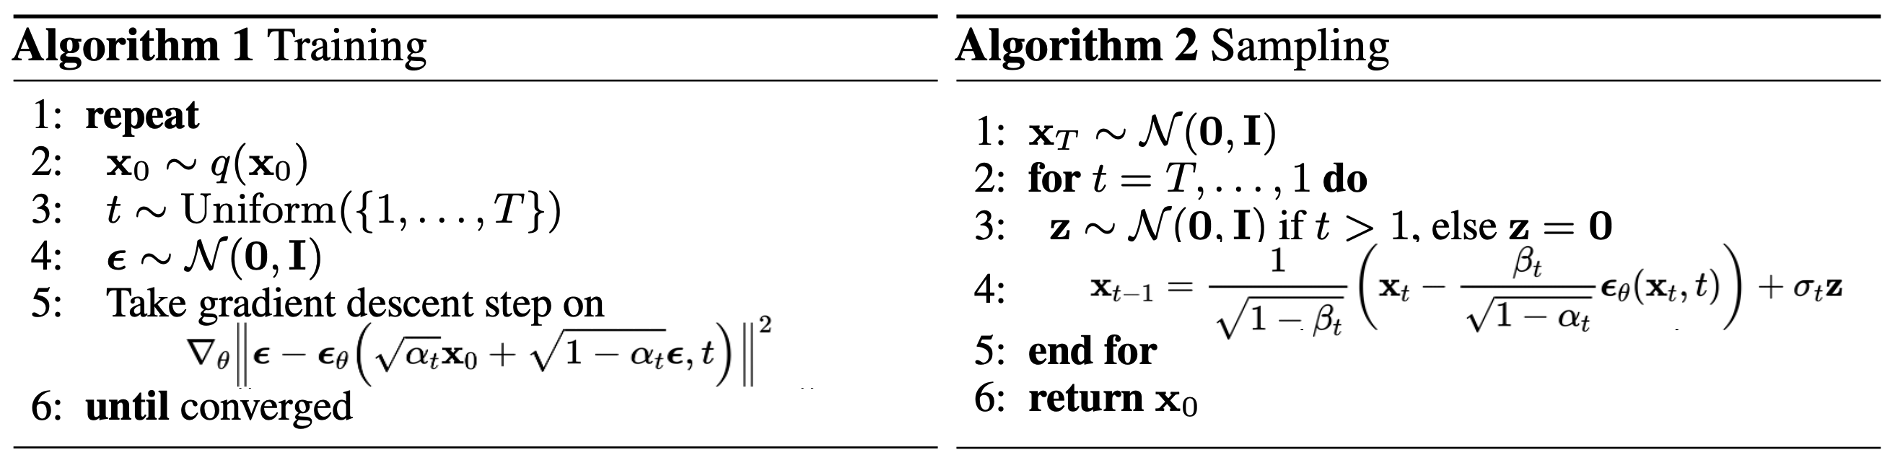" width="700"><figcaption>Ho et al., 2020より一部表記を変更</figcaption></figure>

## 3.ネットワークの定義

上記のノイズ推定を行うモデルを定義します．

構造としてはU-Net [[3]](https://arxiv.org/abs/1505.04597) に近いものを用います．U-Netはencoder-decoderの構造で，encoderのブロックからdecoderのブロックへ直接のskip connectionがあるのが特徴です．

<!--
<br>

**U-Netの構造**

<figure align="center"><img src="https://drive.google.com/uc?id=1_Hej_VTgdUWGsxxIuyZACCGjpbCGIUi6" width="600"><figcaption>Ronneberger et al., 2015</figcaption></figure>
-->

### 3.1 ヘルパー関数

In [ ]:
def exists(x):
    return x is not None


class Residual(nn.Module):
    """ラップした層にskip connectionを追加するクラス"""
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x


class PreNorm(nn.Module):
    """ラップした層の前にgroup normalization [7]を追加するクラス"""
    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn
        self.norm = nn.GroupNorm(num_groups=1, num_channels=dim)

    def forward(self, x):
        x = self.norm(x)
        return self.fn(x)


def Upsample(dim, dim_out=None):
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode="nearest"),
        nn.Conv2d(dim, dim_out if exists(dim_out) else dim, kernel_size=3, padding=1),
    )

def Downsample(dim, dim_out=None):
    return nn.Conv2d(
        dim, dim_out if exists(dim_out) else dim, kernel_size=4, stride=2, padding=1
    )

### 3.2 Positional encoding

<!--
ネットワークのパラメータは時間 $t$（ノイズレベル）にわたって共有されるので，
-->
バッチ内それぞれの画像がどのタイムステップ $t$（ノイズレベル）にあるのかの情報をネットワークに与えます．

ここではTransformerの元論文 [[4]](https://arxiv.org/abs/1706.03762) と同じsinusoidal positional encodingを用います．

\begin{aligned}
PE_{(pos,2i)} &= sin(pos\,/\,10000^{2i\,/\,d_{model}}) \\
PE_{(pos,2i+1)} &= cos(pos\,/\,10000^{2i\,/\,d_{model}})
\end{aligned}

<!--
`SinusoidalPositionEmbeddings`モジュールは，入力としてバッチ内のサンプルのノイズレベル`( batch_size, 1 )`を受け取り、これをposition embeddingの次元数`( batch_size, dim )`にして返します．これが後に各残差ブロックに追加されます．
-->


In [ ]:
class SinusoidalPositionEncoding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        """整数のタイムステップを受け取り，そのembeddingベクトルを返す．
        Args:
            time ( b, ): 拡散過程のタイムステップ．Positional encoding式のposに対応
        Returns:
            pos_enc ( b, time_emb_dim ): Positional encoding
        """
        half_dim = self.dim // 2

        pos_enc = math.log(10000) / (half_dim - 1)  # scalar
        pos_enc = torch.exp(torch.arange(half_dim, device=time.device) * -pos_enc)  # ( time_emb_dim // 2, )
        pos_enc = time[:, None] * pos_enc[None, :]  # ( batch, 1 ) * ( 1, time_emb_dim // 2 ) -> ( batch, time_emb_dim // 2 )
        pos_enc = torch.cat((pos_enc.sin(), pos_enc.cos()), dim=-1)  # ( batch, time_emb_dim )

        return pos_enc

### 3.3 Wide ResNetブロック

次に，U-Netモデルのコアとなるブロックを定義します．DDPMではWide ResNet [[5]](https://arxiv.org/abs/1605.07146) ブロックが用いられました．

In [ ]:
class Block(nn.Module):
    def __init__(self, dim, dim_out, groups=8):
        super().__init__()
        self.proj = nn.Conv2d(dim, dim_out, 3, padding=1)
        self.norm = nn.GroupNorm(groups, dim_out)
        # https://pytorch.org/docs/stable/generated/torch.nn.SiLU.html
        self.act = nn.SiLU()

    def forward(self, x, scale_shift=None):
        """
        Args:
            x ( b, dim, h', w' ): UNetの中間表現
        Returns:
            x ( b, dim_out, h', w' ): 時間情報が追加された中間表現
        """
        x = self.proj(x)
        x = self.norm(x)

        if exists(scale_shift):
            scale, shift = scale_shift
            x = x * (scale + 1) + shift

        return self.act(x)

class ResnetBlock(nn.Module):
    def __init__(self, dim, dim_out, *, time_emb_dim=None, groups=8):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, dim_out * 2)
        ) if exists(time_emb_dim) else None

        self.block1 = Block(dim, dim_out, groups=groups)
        self.block2 = Block(dim_out, dim_out, groups=groups)
        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()

    def forward(self, x, time_emb=None):
        """
        Args:
            x ( b, dim, h', w' ): UNetの中間表現
            time_emb ( b, time_emb_dim ): 拡散過程のタイムステップ情報
        Returns:
            x ( b, dim_out, h', w' )
        """
        scale_shift = None

        if exists(self.mlp) and exists(time_emb):
            time_emb = self.mlp(time_emb)  # ( b, dim_out * 2 )
            time_emb = rearrange(time_emb, "b c -> b c 1 1")  # ( b, dim_out * 2, 1, 1 )
            scale_shift = time_emb.chunk(2, dim=1)  # tuple(( b, dim_out, 1, 1 ), ( b, dim_out, 1, 1 ))

        h = self.block1(x, scale_shift=scale_shift)
        h = self.block2(h)

        return h + self.res_conv(x)

### 3.4 Attention module

畳み込みブロックの間に追加されるattention moduleを定義します．ここではefficient attention (linear attention) [[6]](https://arxiv.org/abs/1812.01243) を実装します．

とてもシンプルで，Q, K, Vの行列積をとる順番を変えることで計算量を削減しています．

<!--
アテンションは、NLPや画像認識、から[タンパク質立体構造](https://www.deepmind.com/blog/alphafold-a-solution-to-a-50-year-old-grand-challenge-in-biology)の同定まで、AIの様々な領域で大きな成功を収めた有名なTransformerアーキテクチャ([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)）で用いられたブロックです。
-->

<!--
Phil Wangはの2種類のAttention機構を採用しています。
* 通常の multi-head self-attention（Transformerで使用されているもの）
* linear attention variant ([Shen et al., 2018](https://arxiv.org/abs/1812.01243))
-->

<figure align="center"><img src=" 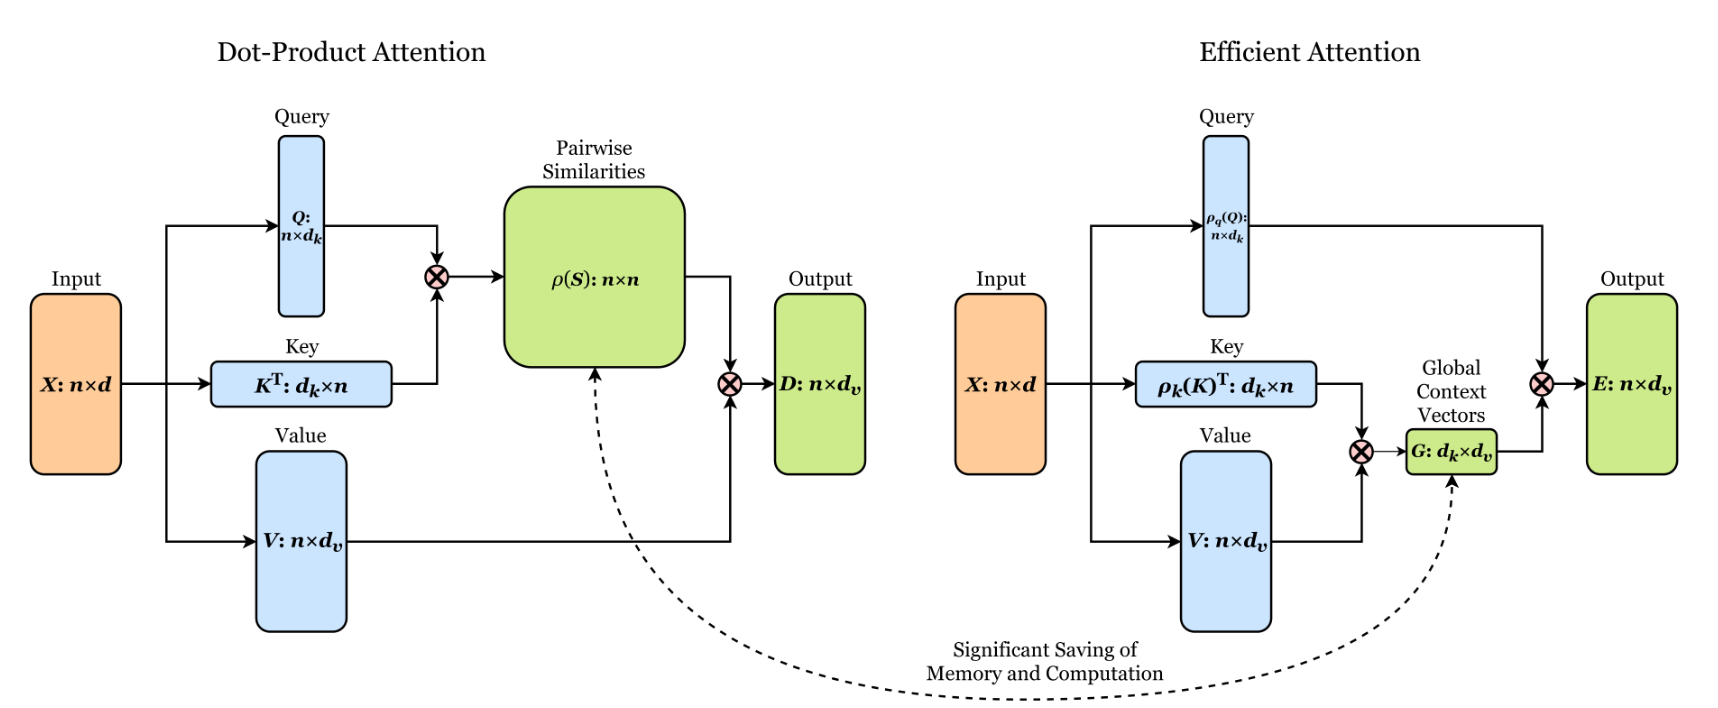" width="600" /><figcaption>Shen et al., 2018</figcaption></figure>

<!--
詳しい説明は、[こちら](https://jalammar.github.io/illustrated-transformer/)などを参照してください。
-->


In [ ]:
class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32, num_mem_kv=4):
        super().__init__()

        self.scale = dim_head ** -0.5
        self.heads = heads
        hidden_dim = dim_head * heads

        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)

        self.to_out = nn.Sequential(
            nn.Conv2d(hidden_dim, dim, 1),
            nn.GroupNorm(1, dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x ( b, dim, h', w' )
        Returns:
            out ( b, dim, h', w' )
        """
        b, c, h, w = x.shape

        q, k, v = self.to_qkv(x).chunk(3, dim=1)
        q = rearrange(q, "b (h c) x y -> b h c (x y)", h=self.heads)
        k = rearrange(k, "b (h c) x y -> b h c (x y)", h=self.heads)
        v = rearrange(v, "b (h c) x y -> b h c (x y)", h=self.heads)
        # ( b, heads, dim_head, h(=x) * w(=y) )

        q = q.softmax(dim=-2)
        k = k.softmax(dim=-1)

        q = q * self.scale

        context = torch.einsum("b h d n, b h e n -> b h d e", k, v)

        out = torch.einsum("b h d e, b h d n -> b h e n", context, q)
        out = rearrange(out, "b h c (x y) -> b (h c) x y", h=self.heads, x=h, y=w)

        return self.to_out(out)

### 3.5 モデル全体の定義

U-Netの全ての構成要素を定義したところで，ネットワーク全体を定義します．

ネットワークは，ノイズ画像とタイムステップ $t$ からなるバッチを入力として受け取り，推定されたノイズを出力します．

<br>

**U-Netの構造**

<figure align="center"><img src=" 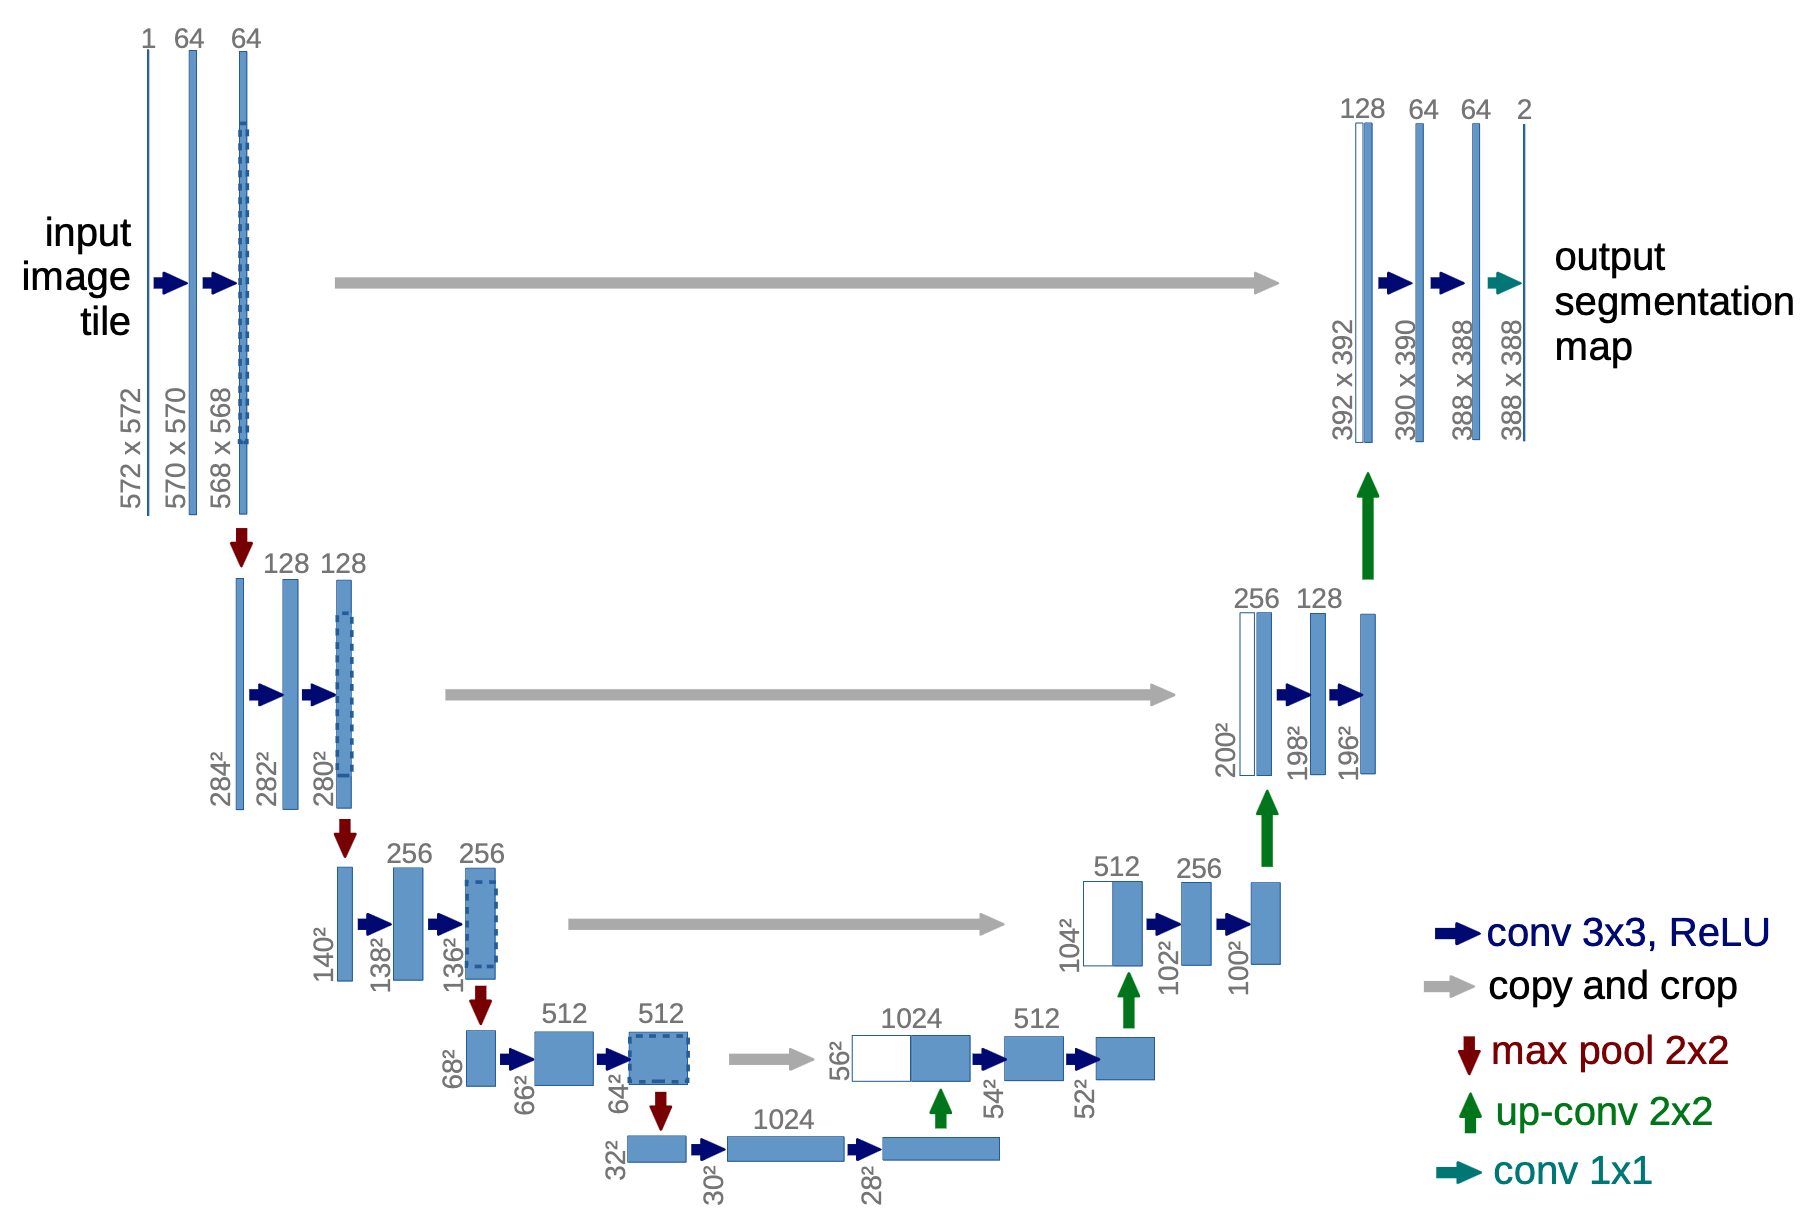" width="500"><figcaption>Ronneberger et al., 2015</figcaption></figure>

<br>

本論文モデルのU-Net以外の特記事項

- ConvolutionブロックがWide ResNet（[PixelCNN++](https://arxiv.org/pdf/1701.05517.pdf)を踏襲）

- Sinusoidal positional encodingでタイムステップ $t$ の情報を追加

- Self-attentionを使用

- Group normalizationを使用（PixelCNN++でweight normだったものを単純化）

<!--
各のtensorの形状は以下のようになります．

- ノイズ画像：`(batch_size, num_channels, height, width)`

- ノイズレベル： `(batch_size, 1)`

- 出力：`(batch_size, num_channels, height, width)`
-->


<!--
### **ネットワークの構築**

- まず，ノイズ画像のバッチに対して畳み込み層を適用し，ノイズレベルに対してposition embeddingを計算する．
- 次に，一連のダウンサンプリングを適用する．各ダウンサンプリングステージは，「2つのWide ResNetブロック + グループ正規化 + attention + residual connection + ダウンサンプル操作」 で構成されている．
- ネットワークの中間(ボトルネック部)で、再びWide ResNetブロック + attention + Wide ResNetブロックが適用される．
- 次に，一連のアップサンプリングを適用する．各アップサンプリングステージは，2つのWide ResNetブロック+ グループ正規化 + attention + residual connection + アップサンプル処理から構成される．
- 最後に，Wide ResNetブロックと畳み込み層が適用される．
-->




In [ ]:
class Unet(nn.Module):
    def __init__(
        self,
        dim, # image_size
        init_dim=None,
        out_dim=None,
        dim_mults=(1, 2, 4, 8),
        channels=3,
        with_time_emb=True,
        resnet_block_groups=8,
        convnext_mult=2,
    ):
        super().__init__()

        # determine dimensions
        self.channels = channels

        # 最初の畳み込み
        init_dim = init_dim if exists(init_dim) else dim // 3 * 2
        self.init_conv = nn.Conv2d(channels, init_dim, kernel_size=7, padding=3)

        # Wide ResNet ブロック（functools.partial()でgroupsだけ固定して使い回す）
        ResnetBlock_ = partial(ResnetBlock, groups=resnet_block_groups)

        # position (time) encoding
        if with_time_emb:
            time_dim = dim * 4
            self.time_mlp = nn.Sequential(
                SinusoidalPositionEncoding(dim),
                nn.Linear(dim, time_dim),
                nn.GELU(),
                nn.Linear(time_dim, time_dim),
            )
        else:
            time_dim = None
            self.time_mlp = None

        # 各層の入力・出力次元数のリスト
        dims = [init_dim, *map(lambda m: dim * m, dim_mults)]
        in_out = list(zip(dims[:-1], dims[1:]))

        num_resolutions = len(in_out)

        # エンコーダ
        self.downs = nn.ModuleList([])

        for ind, (dim_in, dim_out) in enumerate(in_out):
            is_last = ind >= (num_resolutions - 1)

            self.downs.append(nn.ModuleList(
                    [
                        ResnetBlock_(dim_in, dim_in, time_emb_dim=time_dim),
                        ResnetBlock_(dim_in, dim_in, time_emb_dim=time_dim),
                        Residual(PreNorm(dim_in, LinearAttention(dim_in))),
                        Downsample(dim_in, dim_out) if not is_last else nn.Conv2d(dim_in, dim_out, 3, padding=1),
                    ]
                )
            )

        # ボトルネック部分
        mid_dim = dims[-1]
        self.mid_block1 = ResnetBlock_(mid_dim, mid_dim, time_emb_dim=time_dim)
        self.mid_attn = Residual(PreNorm(mid_dim, LinearAttention(mid_dim)))
        self.mid_block2 = ResnetBlock_(mid_dim, mid_dim, time_emb_dim=time_dim)

        # デコーダ
        self.ups = nn.ModuleList([])

        for ind, (dim_in, dim_out) in enumerate(reversed(in_out)):
            is_last = ind == (num_resolutions - 1)

            self.ups.append(nn.ModuleList(
                    [
                        ResnetBlock_(dim_out + dim_in, dim_out, time_emb_dim=time_dim),
                        ResnetBlock_(dim_out + dim_in, dim_out, time_emb_dim=time_dim),
                        Residual(PreNorm(dim_out, LinearAttention(dim_out))),
                        Upsample(dim_out, dim_in) if not is_last else nn.Conv2d(dim_out, dim_in, 3, padding=1),
                    ]
                )
            )

        # 最後の畳み込み
        out_dim = out_dim if exists(out_dim) else channels
        self.final_res_block = ResnetBlock_(init_dim * 2, init_dim, time_emb_dim=time_dim)
        self.final_conv = nn.Conv2d(init_dim, out_dim, 1)

    def forward(self, x, time):  # time: ( b, )
        b = x.shape[0]

        x = self.init_conv(x)
        r = x.clone()

        # Embedされた時間情報
        t = self.time_mlp(time) if exists(self.time_mlp) else None # ( B, time_emb_dim )

        # エンコーダ-デコーダ間のskip connection
        h = []

        # エンコーダ
        for block1, block2, attn, downsample in self.downs:
            x = block1(x, t) # 全レイヤーに対して時間情報を与えている
            h.append(x)

            x = block2(x, t)
            x = attn(x)
            h.append(x)

            x = downsample(x)

        # ボトルネック
        x = self.mid_block1(x, t)
        x = self.mid_attn(x)
        x = self.mid_block2(x, t)

        # デコーダ
        for block1, block2, attn, upsample in self.ups:
            x = torch.cat((x, h.pop()), dim=1)
            x = block1(x, t)

            x = torch.cat((x, h.pop()), dim=1)
            x = block2(x, t)
            x = attn(x)

            x = upsample(x)

        x = torch.cat((x, r), dim=1)

        x = self.final_res_block(x, t)

        return self.final_conv(x)

## 4.データセット / データローダー

<!--
ここでは，Fashion MNISTを$[-1,1]$に線形スケーリングして用います．

次に，データセット全体にスケーリングと`RandomHorizontalFlip()`を適用する関数を定義します．これには [`with_transform`](https://huggingface.co/docs/datasets/v2.2.1/en/package_reference/main_classes#datasets.Dataset.with_transform)関数を使います．
-->

FashionMNIST

In [ ]:
image_size = 24
channels = 1
batch_size = 128
dim_mults = (1, 2, 4)

transform = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),  # [0,255] -> [0,1]
        transforms.ToTensor(),  # [0,255] -> [0.0,1.0]にスケーリング
        transforms.Lambda(lambda t: (t * 2) - 1),
    ]
)

dataloader = DataLoader(
    torchvision.datasets.FashionMNIST('data/fashion-mnist', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True,
)

# 可視化しておきます．
fig = plt.figure(figsize=(10,3))

images, _ = next(iter(dataloader))
for i in range(16):
  ax = fig.add_subplot(2, 8, i+1)
  ax.imshow(images[i].numpy().transpose(1, 2, 0) * 0.5 + 0.5, cmap="gray")
  ax.axis("off")

plt.tight_layout()

CIFAR10

In [ ]:
image_size = 32
channels = 3
batch_size = 128
dim_mults = (1, 2, 4, 8)

transform = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ]
)

dataloader = DataLoader(
    torchvision.datasets.CIFAR10('data/cifar10', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True,
)

# 可視化しておきます．
fig = plt.figure(figsize=(10,3))

images, _ = next(iter(dataloader))
for i in range(16):
  ax = fig.add_subplot(2, 8, i+1)
  ax.imshow(images[i].numpy().transpose(1, 2, 0) * 0.5 + 0.5)
  ax.axis("off")

plt.tight_layout()

## 5.学習 (Algorithm 1) の実装

<figure align="center"><img src=" 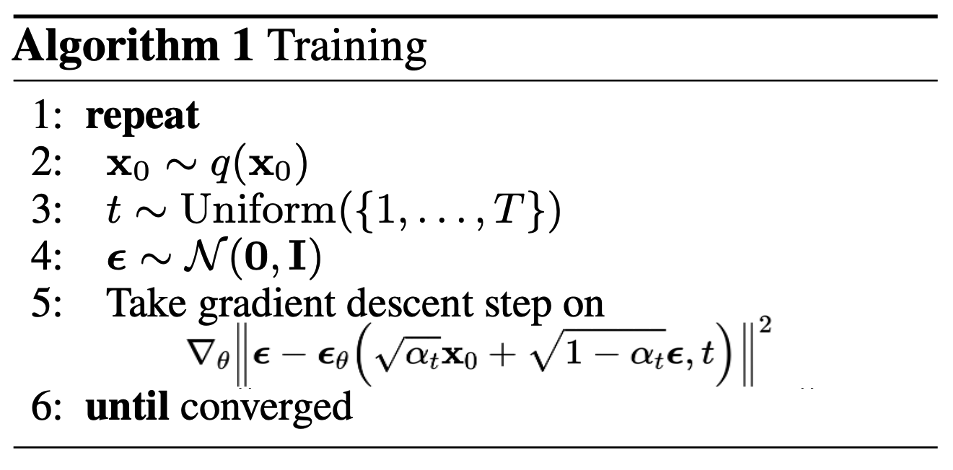" width="400"><figcaption>Ho et al., 2020より一部表記を変更</figcaption></figure>

<br>

まず，$\beta_t$のスケジューリングをする関数と，それに伴う $\alpha_t = \prod_{i=1}^T1 - \beta_i$ などのハイパーパラメータを定義します．

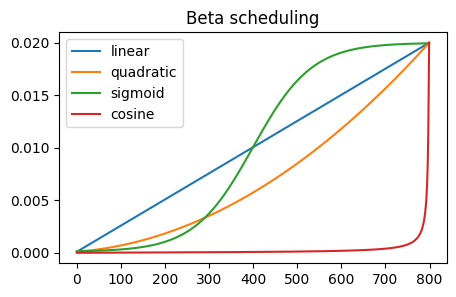

In [ ]:
timesteps = 800 # T

# 様々なbeta scheduling

def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, timesteps)

def quadratic_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

def sigmoid_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    betas = torch.linspace(-6, 6, timesteps)
    return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start

def cosine_beta_schedule(timesteps, s=0.008, beta_end=0.02):
    """[8] で提案されたcosine schedule"""
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999) * beta_end

fig = plt.figure(figsize=(5, 3))
plt.plot(linear_beta_schedule(timesteps), label='linear')
plt.plot(quadratic_beta_schedule(timesteps), label='quadratic')
plt.plot(sigmoid_beta_schedule(timesteps), label='sigmoid')
plt.plot(cosine_beta_schedule(timesteps), label='cosine')
plt.legend()
plt.title('Beta scheduling')


# betaのスケジューリング
betas = linear_beta_schedule(timesteps)

# alpha
alphas_cumprod = torch.cumprod(1. - betas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

Forward diffusion processはデータ分布からのサンプル $\mathbf{x}_0$ に徐々にノイズを加えていく過程ですが，[上述](#scrollTo=PXLrG8XGD-TW)のように，任意のステップ$t$におけるノイズ入りサンプル $\mathbf{x}_t$ は，reparameterizationで $\mathbf{x}_0$ を使ってサンプリングできます．

<br>

$$
\mathbf{x}_t = \sqrt{\alpha_t} \mathbf{x}_0 + \sqrt{1- \alpha_t  } \mathbf{\epsilon}
\qquad \epsilon \sim \mathcal{N}(0,I)
$$

In [ ]:
def extract(a, t, x_shape: torch.Size):
    """各サンプルのステップtに対応するインデックスの要素を抽出する
    Args:
        a ( T, ): alphasやbetas
        t ( b, ): バッチ内各サンプルのタイムステップt
        x_shape: 画像サイズ
    Returns:
        out ( b, 1, 1, 1 ): xとの計算に使うためxに次元数を合わせて返す
    """
    batch_size = t.shape[0]

    out = a.gather(-1, t.to(a.device))
    # https://pytorch.org/docs/stable/generated/torch.gather.html
    # out = torch.stack([a[_t] for _t in t.to(a.device)]) と同じ

    # xと同じ次元数にする
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

def q_sample(x_start, t, noise):
    """Reparameterizationを用いて，実画像x_0からノイズ画像x_tをサンプリングする（拡散過程）
    Args:
        x_start ( b, c, h, w ): 実画像x_0
        t ( b, ): バッチ内各サンプルのタイムステップt
        noise ( b, c, h, w ): 標準ガウス分布からのノイズ (epsilon)
    Returns:
        x_noisy: ( b, c, h, w ): ノイズ画像x_t
    """
    alphas_cumprod_t = extract(alphas_cumprod, t, x_start.shape) # ( b, 1, 1, 1 )

    return # WRITE ME

この関数がモデルと実画像 $\mathbf{x}_0$ を受け取り，ロスの計算まで行います．

<!--`denoise_model`はU-Netのことです。
本実装では、目的関数にHuber lossを採用しています。-->


In [ ]:
def p_losses(denoise_model, x_start, t, noise=None, loss_type="l2"):
    """
    Args:
        denoise_model ( nn.Module ): U-Net
        x_start ( b, c, h, w ): 実画像x_0
        t ( b, ): バッチ内各サンプルのタイムステップt
    """
    # [Algorithm 1 4行目] epsilonを標準正規分布からサンプリング
    if noise is None:
        noise = # WRITE ME

    # [Algorithm 1 5行目] x_tをサンプリング -> U-Netでそのノイズを予測
    x_noisy = # WRITE ME

    predicted_noise = denoise_model(x_noisy, t) # U-Net

    if loss_type == 'l1':
        loss = F.l1_loss(noise, predicted_noise)
    elif loss_type == 'l2':
        loss = F.mse_loss(noise, predicted_noise)
    elif loss_type == "huber":
        # https://pytorch.org/docs/stable/generated/torch.nn.SmoothL1Loss.html
        loss = F.smooth_l1_loss(noise, predicted_noise)
    else:
        raise NotImplementedError()

    return loss

## 6.サンプリング (Algorithm 2) の実装

生成結果を可視化しながら学習するため，先にサンプリングのための関数を定義しておきます．

Algorithm 2 に従い，ノイズ $\mathbf{x}_T \sim \mathcal{N}(0,I)$ から $\mathbf{x}_0$ を生成します．ここでも逆過程のマルコフ連鎖をたどる必要があるため，DDPMからの画像生成にはGANなどに比べ時間がかかります．

<figure align="center"><img src=" 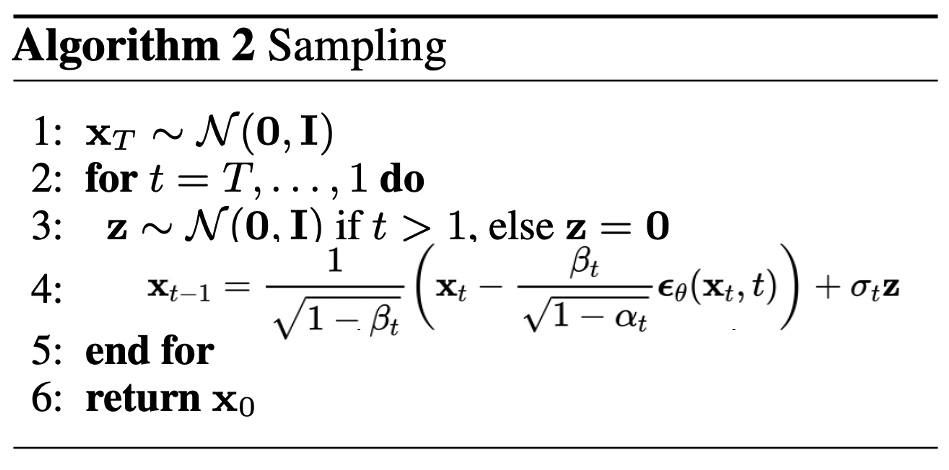" width="400"><figcaption>Ho et al., 2020より一部表記を変更</figcaption></figure>

<!--
標準正規分布からサンプリングした $\mathbf{x}_T$ をニューラルネットワークに入れ，（学習した条件付き確率を使って）徐々にノイズを除去していきます．

上に示したように，ノイズ予測器を用いて平均のreparametrizationを行うことで，わずかにノイズ除去された画像 $\mathbf{x}_{t-1 }$ を導き出しています（ただし分散は既知）．
-->

$$
q(\mathbf{x}_{t-1}|\mathbf{x}_t, \mathbf{x}_0) = \mathcal{N}(\mathbf{x}_{t-1; }\tilde{\mu}_t(\mathbf{x}_t, \mathbf{x}_0), \tilde{\beta}_tI)
$$

<br>

- [$\mu_{\theta}$ のreparameterization](#scrollTo=7RkHHnZCNrhu)を用いて平均の推定値を計算

-  分散 $\sigma_t^2(=\tilde{\beta}_t)$ の推定量は以下になります．（講義スライドp.37．[こちら](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/)も参照）

$$
\tilde{\beta}_t = \frac{1 - \alpha_{t-1}}{1 - \alpha_t} \beta_t
$$

In [ ]:
# calculations for posterior q(x_{t-1} | x_t, x_0)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

@torch.no_grad()
def p_sample(model, x, t_index):
    """1ステップ逆過程を進む
    Args:
        model ( nn.Module ): U-Net
        x ( b, c, h, w ): ノイズ画像x_t
        t_index ( int ): サンプリングループにおける現在のタイムステップt（サンプル共通）
    Returns:
        x ( b, c, h, w ): ノイズ画像x_{t-1} or 実画像x_0
    """
    t = torch.full((x.shape[0],), t_index, device=x.device, dtype=torch.long) # ( b, )

    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(torch.sqrt(1.0 - alphas_cumprod), t, x.shape)
    coef_t = extract(torch.sqrt(1.0 / (1. - betas)), t, x.shape)

    """[Algorithm 2 3/4行目]"""

    # モデルが予測したノイズepsilonがreparameterizationの平均に使われる
    model_mean = coef_t * (
        x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
    )

    # t=0以外ではノイズを足して返す
    if t_index == 0:
        return model_mean
    else:
        posterior_variance_t = extract(posterior_variance, t, x.shape)
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_variance_t) * noise

@torch.no_grad()
def p_sample_loop(model, image_size, batch_size=16, channels=3):
    """逆過程のステップを繰り返し，画像を生成する
    Args:
        model ( nn.Module ): U-Net
        image_size ( int ): 画像サイズ
    Returns:
        imgs ( b, c, h, w ): 生成画像
    """
    device = next(model.parameters()).device

    # [Algorithm 2 1行目] 純粋なノイズから逆過程を始める
    shape = (batch_size, channels, image_size, image_size)
    img = torch.randn(shape, device=device)

    # [Algorithm 2 2行目] ループ
    imgs = []
    for t in tqdm(reversed(range(0, timesteps)), desc='sampling loop time step', total=timesteps):
        img = p_sample(model, img, t)
        imgs.append(img.cpu().numpy())

    return imgs

## 7.学習の実行

<figure align="center"><img src=" 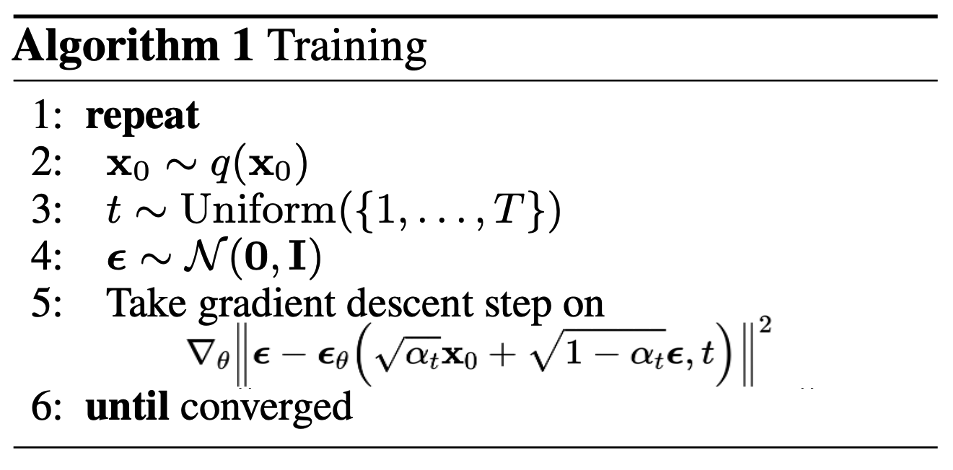" width="400"><figcaption>Ho et al., 2020より一部表記を変更</figcaption></figure>

ロスの推移とサンプリング結果を表示するための関数を定義しておきます．

In [ ]:
def display_process(epoch, losses, samples=None):
    plt.gcf().clear()

    fig, axs = plt.subplots(1, 2, figsize=(10, 7))
    fig.subplots_adjust(left=0, right=1, bottom=0, top=0.5, hspace=0.05, wspace=0.05)

    axs[0].plot(losses, label="train loss")
    axs[0].set_xlabel("Total steps")
    axs[0].set_ylabel("Losses")
    axs[0].legend()

    axs[1].axis("off")
    axs[1].set_title(f"Epoch {epoch}")

    if exists(samples):
        samples = np.clip(samples.transpose(0, 2, 3, 1) * 0.5 + 0.5, 0.0, 1.0)
        for i in range(16):
            ax = fig.add_subplot(4, 8, (i // 4 + 1) * 4 + i + 1, xticks=[], yticks=[])
            ax.imshow(samples[i], cmap="gray" if samples.shape[-1] == 1 else None)
            ax.axis("off")

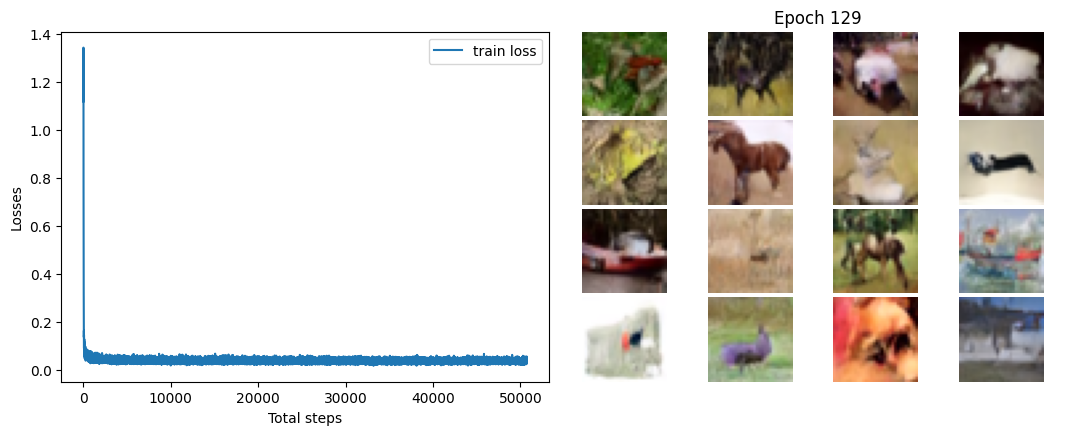

sampling loop time step:   0%|          | 0/800 [00:00<?, ?it/s]

In [ ]:
device = "cuda"

model = Unet(
    dim=image_size,
    channels=channels,
    dim_mults=dim_mults,
    resnet_block_groups=4,
).to(device)
# print(f"Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

epochs = 500

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[int(epochs * ratio) for ratio in [0.5, 0.8]],
    gamma=0.2,
)

losses = []
samples = None

for epoch in range(epochs):
    for step, (images, _) in enumerate(dataloader):
        optimizer.zero_grad()

        b = images.shape[0]
        # [Algorithm 1 2行目] 真のデータをバッチで受け取る
        images = images.to(device) # ( b, c, h, w )

        # [Algorithm 1 3行目] tを一様分布からサンプリング
        t = torch.randint(0, timesteps, (b,), device=device).long()

        # [Algorithm 1 4/5行目] 実行
        loss = p_losses(model, images, t, loss_type="l2")

        losses.append(loss.item())
        if step % 100 == 0:
            display_process(epoch, losses, samples)
            display.clear_output(wait=True)
            display.display(pl.gcf())
            plt.close()

        loss.backward()
        optimizer.step()

    scheduler.step()

    samples = p_sample_loop(
        model,
        image_size=image_size,
        batch_size=16,
        channels=channels,
    )[-1]

最後に，reverse denoising processの可視化を行います．

In [ ]:
# 64枚サンプル
samples = p_sample_loop(model, image_size=image_size, batch_size=64, channels=channels)
cmap = "gray" if samples[-1].shape[1] == 1 else None

fig = plt.figure(figsize=(10,12))

for i in range(64):
  ax = fig.add_subplot(8, 8, i+1)
  ax.set_title(str(i))
  ax.imshow(np.clip(samples[-1][i].transpose(1, 2, 0) * 0.5 + 0.5, 0.0, 1.0), cmap=cmap)
  ax.axis("off")

plt.tight_layout()

`IDX`で選択した番号のreverse denoising processを可視化します．

In [ ]:
# 指定したidxの生成過程を可視化
IDX = 41

fig = plt.figure()
ims = []
for i in range(timesteps):
    im = plt.imshow(np.clip(samples[i][IDX].transpose(1, 2, 0) * 0.5 + 0.5, 0.0, 1.0), animated=True, cmap=cmap)
    ims.append([im])

animate = animation.ArtistAnimation(fig, ims, interval=50, blit=True, repeat_delay=1000)

rc('animation', html='jshtml')
animate

## 8.参考文献

[[1]](https://arxiv.org/abs/2006.11239) Ho et al., 2020 "Denoising Diffusion Probabilistic Models", arXiv:2006.11239

[[2]](https://arxiv.org/abs/1503.03585) Sohl-Dickstein et al., 2015 "Deep Unsupervised Learning using Nonequilibrium Thermodynamics", arXiv:1503.03585

[[3]](https://arxiv.org/abs/1505.04597) Ronneberger et al., 2015 "U-Net: Convolutional Networks for Biomedical Image Segmentation", arXiv:1505.04597

[[4]](https://arxiv.org/abs/1706.03762) Vaswani et al., 2017 "Attention Is All You Need", arXiv:1706.03762

[[5]](https://arxiv.org/abs/1605.07146) Zagoruyko et al., 2016 "Wide Residual Networks", arXiv:1605.07146

[[6]](https://arxiv.org/abs/1812.01243) Shen et al., 2018 "Efficient Attention: Attention with Linear Complexities", arXiv:1812.01243

[[7]]((https://arxiv.org/abs/1803.08494) Wu et al., 2018 "Group Normalization", arXiv:1803.08494

[[8]](https://arxiv.org/abs/2102.09672) Nichol et al., 2021 "Improved Denoising Diffusion Probabilistic Models", arXiv:2102.09672

[[9]](https://github.com/lucidrains/denoising-diffusion-pytorch) GitHub repo "denoising-diffusion-pytorch" by Phil Wang

[[10]](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/) Blog post "What are Diffusion Models?" by Lilian Weng